In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from scipy import stats


StockMarketAna = pd.read_csv('all_stocks_5yr.csv')
print(StockMarketAna.head().to_string())
print("\n")
print(StockMarketAna.info())
print("\n")
print(StockMarketAna.shape)


print("Data Shape:", StockMarketAna.shape)
print("\nData Types:\n", StockMarketAna.dtypes)
print("\nMissing Values:\n", StockMarketAna.isnull().sum())
print("\nSummary Statistics of Stock Prices (2013-2018):\n", StockMarketAna.describe(include='all'))



         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB
None


(619040, 7)
Data Shape: (619040, 7)

Data Types:
 date       object
open      float64
high      float64
low       float64
close     fl

In [ ]:
print("\n I am Handling Missing Values By Filling Them with Median and Mode Values Respectively \n")

StockMarketAna['open']  = StockMarketAna['open'].fillna(StockMarketAna['open'].mean())
StockMarketAna['high']  = StockMarketAna['high'].fillna(StockMarketAna['high'].mean())
StockMarketAna['low']   = StockMarketAna['low'].fillna(StockMarketAna['low'].mean())

StockMarketAna['Name'] = StockMarketAna['Name'].fillna(StockMarketAna['Name'].mode()[0])
print("The Missing Values After Handling is:\n", StockMarketAna.isnull().sum())
print("\nThe Shape After Handling is:\n", StockMarketAna.shape)
print("\n The First 5 Rows After Handling is:\n", StockMarketAna.head().to_string())


 Handling Missing Values By Filling Them with Median and Mode Values Respectively 

The Missing Values After Handling is:
 date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

The Shape After Handling is:
 (619040, 7)

 The First 5 Rows After Handling is:
          date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL


 
 Boxplot for top 10 companies 



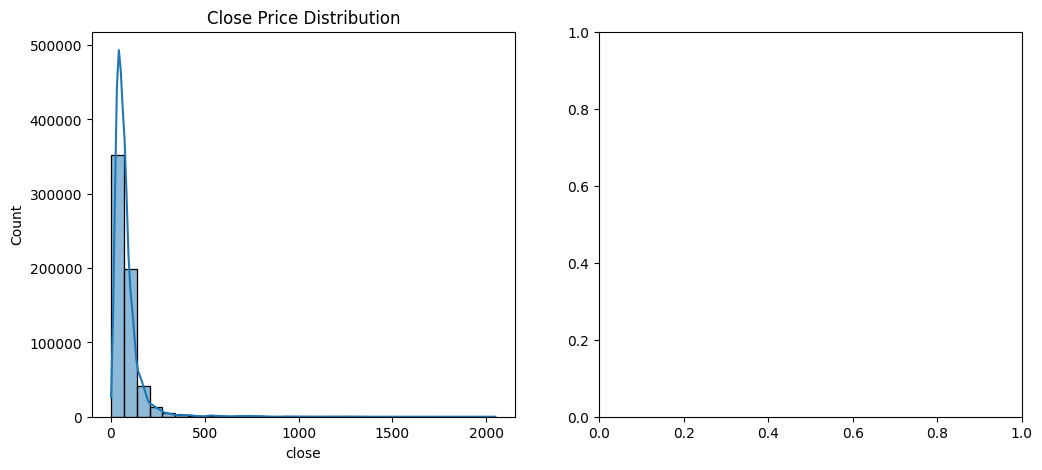

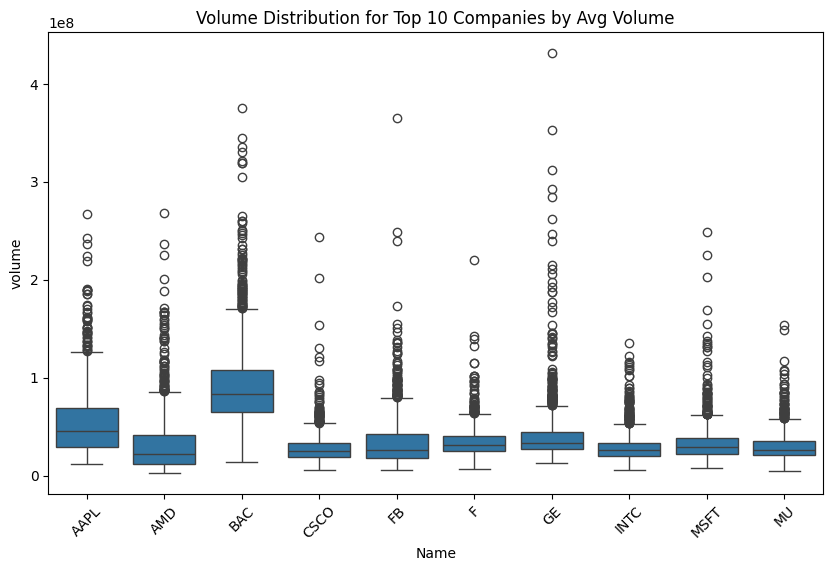


 Count of Records (Top 10 Companies with most rows) 
 


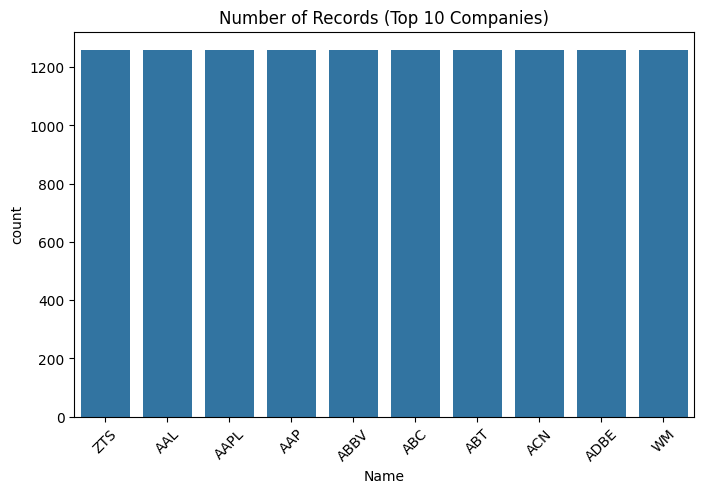

In [ ]:
# 1. Histogram of Closing Prices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(StockMarketAna['close'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Close Price Distribution')


highstocks = StockMarketAna.groupby('Name')['volume'].mean().nlargest(10).index
hightstockdata = StockMarketAna[StockMarketAna['Name'].isin(highstocks)]

print(" \n I am Using Boxplot for top 10 companies \n")
plt.figure(figsize=(10, 6))
sns.boxplot(x='Name', y='volume', data=hightstockdata)
plt.title('Volume Distribution for Top 10 Companies by Avg Volume')
plt.xticks(rotation=45)
plt.show()


print("\n I am Using Count of Records (Top 10 Companies with most rows) \n ") 
highcount = StockMarketAna['Name'].value_counts().nlargest(10).index
hightcount_Data = StockMarketAna[StockMarketAna['Name'].isin(highcount)]

plt.figure(figsize=(8, 5))
sns.countplot(x='Name', data=hightcount_Data, order=highcount)
plt.title('Number of Records (Top 10 Companies)')
plt.xticks(rotation=45)
plt.show()




**1. Close Price Distribution**

Things I Observed : The histogram shows that the vast majority of closing prices are concentrated at the lower end of the spectrum, with a very long tail extending towards higher prices.

**2. Volume Distribution for Top 10 Companies by Average Volume**

Things I Observed: The boxplot for the top 10 companies by average trading volume shows significant variation in the volume patterns. Some companies have very wide boxes and long whiskers, while others are more compact.

**3. Number of Records (Top 10 Companies)**

Observation: The countplot reveals that a small subset of companies (10 out of the entire dataset) contributes a disproportionately high number of records (data points) to the dataset.





 Heatmap of Correlations between Numeric Features 



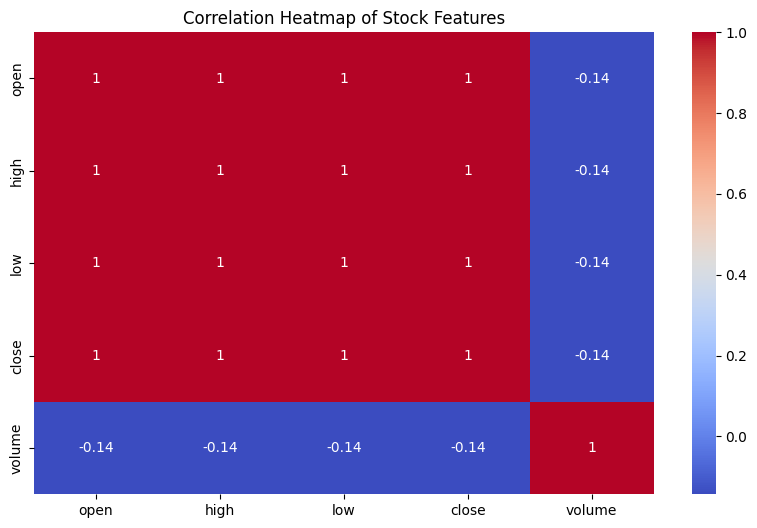


Percentage Distribution of Close Price Categories by Company:

Close_Category        Low     Medium       High
Name                                           
A               52.740270  47.259730   0.000000
AAL             77.204130  22.795870   0.000000
AAP              0.000000   5.321684  94.678316
AAPL             0.000000  23.669579  76.330421
ABBV            13.661636  77.918983   8.419380
...                   ...        ...        ...
XYL             69.420175  30.579825   0.000000
YUM              0.000000  75.853852  24.146148
ZBH              0.000000   9.769658  90.230342
ZION            95.552025   4.447975   0.000000
ZTS             58.538523  41.461477   0.000000

[505 rows x 3 columns]


In [ ]:
print("\n I am Using a Heatmap of Correlations between Numeric Features \n") 
plt.figure(figsize=(10, 6))
sns.heatmap(StockMarketAna.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Stock Features")
plt.show()

StockMarketAna['Close_Category'] = pd.qcut(StockMarketAna['close'], q=3, labels=['Low', 'Medium', 'High'])

crosstab = pd.crosstab(StockMarketAna['Name'], StockMarketAna['Close_Category'], normalize='index') * 100
print("\nPercentage Distribution of Close Price Categories by Company:\n")
print(crosstab)

**The Things I Was Able To Get From The Heatmap Was:**

The correlation heatmap shows that the open, high, low, and close prices are almost perfectly correlated with each other, all having correlation values very close to 1. This indicates that these four price features move together almost identically. In contrast, volume has a weak negative correlation (around –0.14) with all price features, meaning that trading activity does not strongly align with price movements and may even move in the opposite direction in some cases.

In [7]:
print(StockMarketAna.head().to_string())

         date   open   high    low  close    volume Name Close_Category
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL            Low
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL            Low
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL            Low
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL            Low
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL            Low


Found 8508 closing price outliers


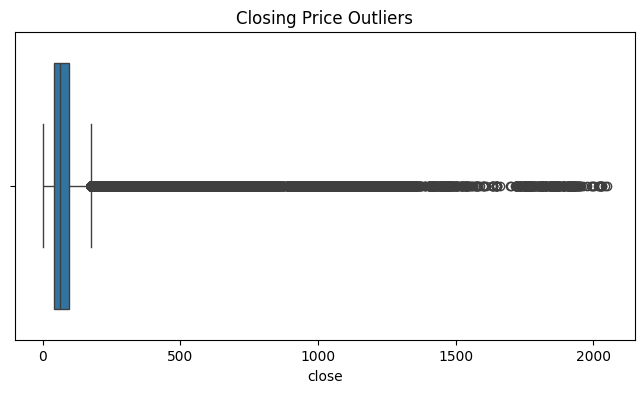

In [ ]:
print("I am Using Boxplot to Detect Outliers in Closing Prices \n")
plt.figure(figsize=(8, 4))
sns.boxplot(x=StockMarketAna['close']).set_title('Closing Price Outliers')
z_scores = np.abs(stats.zscore(StockMarketAna['close']))
Stockoutlier = StockMarketAna[z_scores > 3]
print(f"Found {len(Stockoutlier)} closing price outliers")


Observation: The boxplot shows an extremely right-skewed distribution for closing prices. The "box" (representing the middle 50% of the data) is compressed very close to zero, while the whiskers extend far to the right, indicating numerous extreme values. The code confirms this by detecting a significant number of statistical outliers.

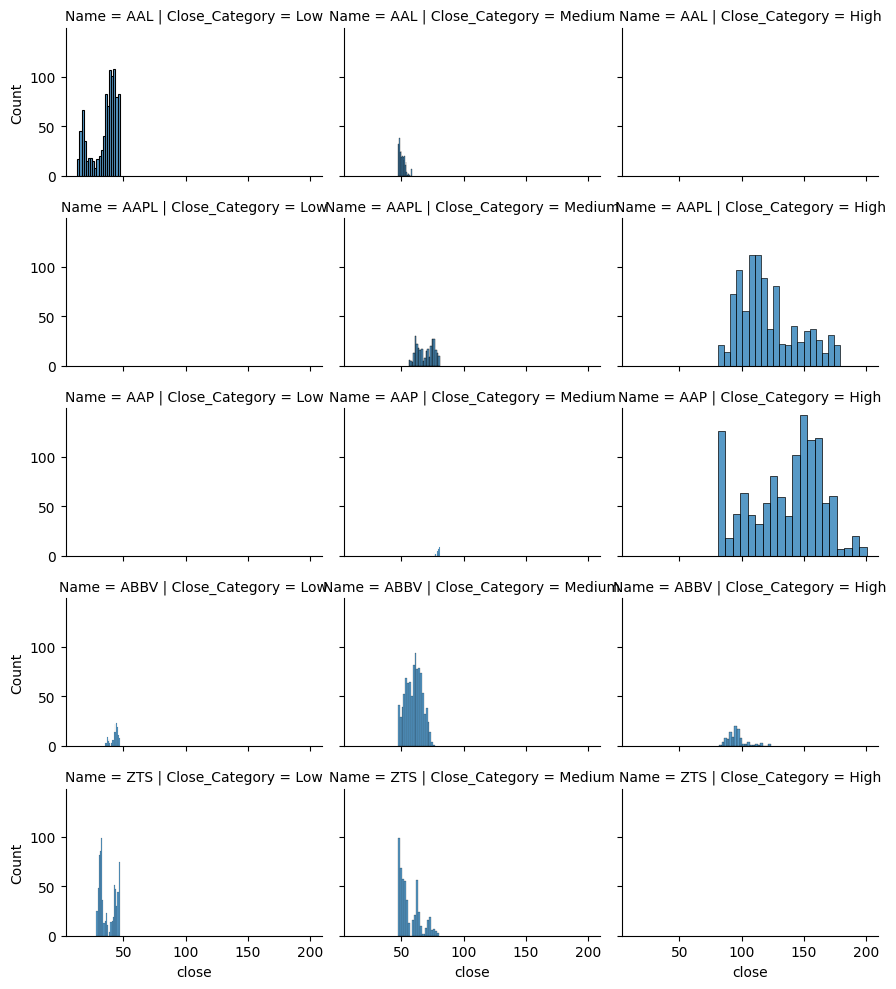

In [7]:
fivehighstock = StockMarketAna['Name'].value_counts().nlargest(5).index
fivstockdata = StockMarketAna[StockMarketAna['Name'].isin(fivehighstock)]

g = sns.FacetGrid(fivstockdata, col='Close_Category', row='Name', height=2, aspect=1.5)
g.map(sns.histplot, 'close', bins=20)
plt.show()


**The Things I Observed from the Faceted Analysis is**

The distributions of closing prices for the top five most frequent stocks show clear differences across categories. AAL falls almost entirely into the low-price range, with only a few instances in the medium and high ranges. AAPL and AAP are concentrated in the high-price range, with almost no presence in low or medium categories. ABBV is spread across the low and medium ranges, with limited representation in the high range. ZTS shows a more balanced distribution, with prices spanning low, medium, and high categories.

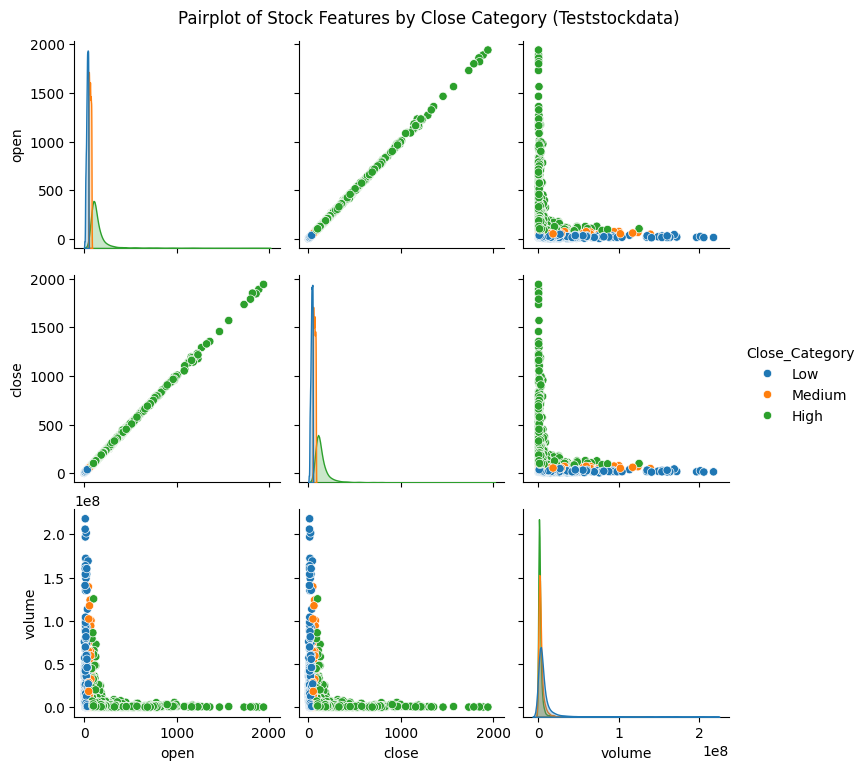

In [8]:
Teststockdata = StockMarketAna.sample(15000, random_state=42)

sns.pairplot(
    Teststockdata[['open', 'close', 'volume', 'Close_Category']], 
    hue='Close_Category'
)
plt.suptitle("Pairplot of Stock Features by Close Category (Teststockdata)", y=1.02)
plt.show()

**The Things I Observed from this**

The pairplot shows that the open price and close price are almost identical, with a very strong positive correlation. Stocks in the Low close category generally have low open and close prices but tend to be traded in higher volumes. Stocks in the Medium close category fall in the middle range for prices and typically show moderate trading volumes. Stocks in the High close category have the highest open and close prices, but they are usually traded in lower volumes.

The distributions of both open and close prices are skewed toward lower values, meaning that most stocks are concentrated in the lower price range. Similarly, volume is also skewed, with most stocks traded at relatively low volumes, while a few stocks trade at very high volumes.